In [1]:
try:
    import ipyvolume as ipv
except:
    !jupyter nbextension enable --py --sys-prefix ipyvolume
    import ipyvolume as ipv 

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
RANDOM_STATE = 42
df = pd.read_parquet("Virgo_results_cut/O3bqtransform_features.parquet")

feature_columns = [col for col in df.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df[feature_columns].to_numpy(dtype="float64")
print(f"X.shape = {X.shape}")

X_max = X.max(axis=1, keepdims=True)

Number of features: 1230
X.shape = (8317, 1230)


In [4]:
for row in X:
    X_norm = X / X_max

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

In [5]:
PCA_COMPONENTS = 40
n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=3,perplexity=90,early_exaggeration=14,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='cosine')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5735


In [6]:
x, y, z = X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2]
ipv.quickscatter(x, y, z, size=1, marker="sphere")

Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…

In [7]:
PCA_COMPONENTS = 40

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=90,early_exaggeration=14,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='cosine')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5735


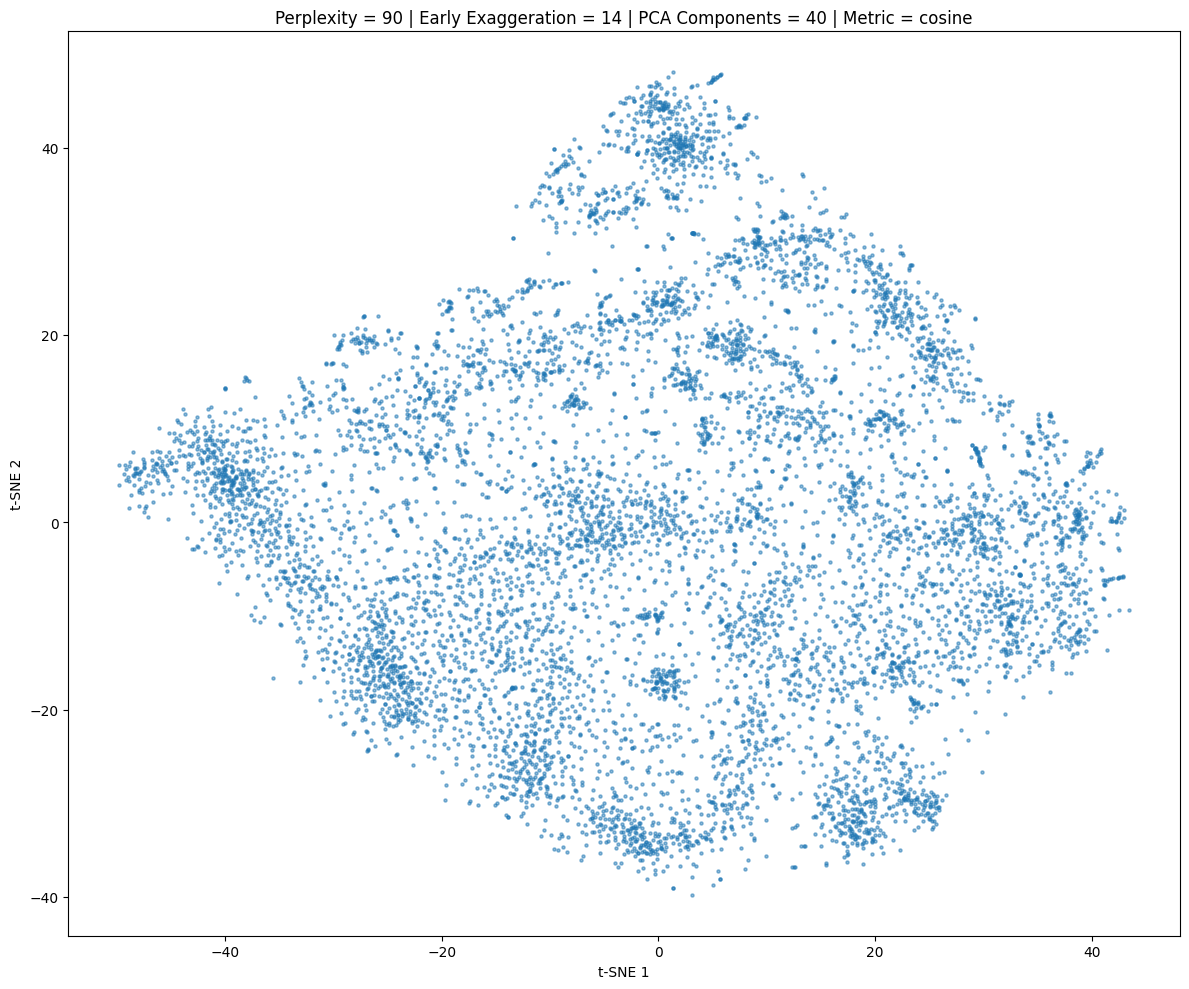

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],s=5,alpha=0.5)
ax.set_title(f"Perplexity = 90 | Early Exaggeration = 14 | PCA Components = {PCA_COMPONENTS} | Metric = cosine")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

In [9]:
from obspy import UTCDateTime

GPS_UNIX_OFFSET = 315964800
GPS_UTC_OFFSET = 18
WINDOW_SECONDS = 12

# -------------------------------------------------------------------
# Read data
# -------------------------------------------------------------------

df_s = pd.read_parquet("Virgo_results_cut/O3bqtransform_features.parquet")
df_g = pd.read_csv("gravity_spy_O3b.csv")

df_g["trigger_time"] = df_g["GPStime"].apply(lambda gps: UTCDateTime(gps + GPS_UNIX_OFFSET - GPS_UTC_OFFSET).datetime)

df_s = df_s[["trigger_time", "file"]].copy()
df_g = df_g[["trigger_time", "label"]].copy()

df_s["trigger_time"] = pd.to_datetime(df_s["trigger_time"], utc=True)
df_g["trigger_time"] = pd.to_datetime(df_g["trigger_time"], utc=True)

# Sort
df_s = df_s.sort_values("trigger_time").reset_index(drop=True)
df_g = df_g.sort_values("trigger_time").reset_index(drop=True)

g_times = df_g["trigger_time"].to_numpy()
s_times = df_s["trigger_time"].to_numpy()

window = pd.Timedelta(seconds=WINDOW_SECONDS).to_numpy()
matched_rows = []
matched_s_indices = set()
matched_g_indices = set()

for s_idx, s_time in enumerate(s_times):
    left = s_time - window
    right = s_time + window

    start = g_times.searchsorted(left, side="left") # Indices of all Gravity Spy triggers >= left
    end = g_times.searchsorted(right, side="right") # Indices of all Gravity Spy triggers <= right
    g_indices = range(start, end) # All Gravity Spy triggers inside [s_time-12s, s_time+12s]

    for g_idx in g_indices:

        matched_rows.append({"file": df_s.iloc[s_idx]["file"],"trigger (df_s)": df_s.iloc[s_idx]["trigger_time"],
                             "trigger (df_g)": df_g.iloc[g_idx]["trigger_time"],"label": df_g.iloc[g_idx]["label"],})

        matched_s_indices.add(s_idx)
        matched_g_indices.add(g_idx)


df_matched = pd.DataFrame(matched_rows,columns=["file","trigger (df_s)","trigger (df_g)","label"])
df_matched = df_matched.reset_index(drop=True)

In [12]:
import os
from pathlib import Path

import numpy as np
import pymupdf
import plotly.graph_objects as go
import ipywidgets as widgets

from IPython.display import display, Image, clear_output

#Warning: WON'T work for unlabeled

HISTOGRAMS_PATH = Path("event_histograms_output")
PDF_DPI = 150
IMAGE_WIDTH = 900

label_map = df_matched.drop_duplicates("file").set_index("file")["label"]
df["label"] = df["file"].map(label_map).fillna("Unlabeled")

df["trigger_time_parsed"] = pd.to_datetime(df["trigger_time"], utc=True)

def make_histogram_filename(ts):
    return f"histogram_{ts.strftime('%Y%m%dT%H%M%S')}_{ts.microsecond // 1000:03d}.pdf"

df["histogram_file"] = df["trigger_time_parsed"].apply(make_histogram_filename)

def get_histogram_path(histogram_file):
    return HISTOGRAMS_PATH / histogram_file


customdata = np.column_stack([
    np.arange(len(df)),
    df["file"].astype(str).values,
    df["label"].astype(str).values,
    df["histogram_file"].astype(str).values,
])

fig = go.FigureWidget(
    data=[go.Scatter(
        x=X_tsne[:, 0], y=X_tsne[:, 1],
        mode="markers",
        marker=dict(size=5, opacity=0.5),
        customdata=customdata,
        hovertemplate=(
            "<b>DataFrame index:</b> %{customdata[0]}<br>"
            "<b>File:</b> %{customdata[1]}<br>"
            "<b>Label:</b> %{customdata[2]}<br>"
            "<b>t-SNE 1:</b> %{x:.3f}<br>"
            "<b>t-SNE 2:</b> %{y:.3f}"
            "<extra></extra>"
        ),
    )]
)

fig.update_layout(
    title=(f"Perplexity = 90 | Early Exaggeration = 14 | PCA Components = {PCA_COMPONENTS} | Metric = cosine"),
    xaxis_title="t-SNE 1", yaxis_title="t-SNE 2", width=1000, height=800, hovermode="closest")

image_output = widgets.Output(layout=widgets.Layout(width="1000px"))

pdf_cache = {}

def render_pdf(pdf_path, dpi=PDF_DPI):
    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"PDF not found:\n{pdf_path}")

    if pdf_path in pdf_cache:
        return pdf_cache[pdf_path]

    pdf = pymupdf.open(pdf_path)

    try:
        if len(pdf) == 0:
            raise ValueError("PDF contains no pages.")
        page = pdf[0]
        zoom = dpi / 72.0
        matrix = pymupdf.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=matrix, alpha=False)
        png_bytes = pix.tobytes("png")

        pdf_cache[pdf_path] = png_bytes
        return png_bytes
    finally:
        pdf.close()


def display_histogram(df_index, file, label, histogram_file, point_position):
    pdf_path = get_histogram_path(histogram_file)

    with image_output:
        clear_output(wait=True)
        print(f"DataFrame index : {df_index}")
        print(f"File            : {file}")
        print(f"Label           : {label}")
        print(f"PDF             : {pdf_path}")
        print(f"t-SNE           : ({X_tsne[point_position, 0]:.4f}, {X_tsne[point_position, 1]:.4f})")
        print()

        try:
            png_bytes = render_pdf(pdf_path, dpi=PDF_DPI)
            display(Image(data=png_bytes, width=IMAGE_WIDTH))

        except FileNotFoundError as e:
            print("ERROR: PDF file was not found.")
            print(e)

        except Exception as e:
            print("ERROR while rendering PDF:")
            print(e)


def on_click(trace, points, selector):
    if not points.point_inds:
        return

    point_position = points.point_inds[0]
    df_index = int(trace.customdata[point_position][0])
    file = str(trace.customdata[point_position][1])
    label = str(trace.customdata[point_position][2])
    histogram_file = str(trace.customdata[point_position][3])
    display_histogram(df_index=df_index, file=file, label=label, histogram_file=histogram_file, point_position=point_position)

fig.data[0].on_click(on_click)
display(fig)
display(image_output)

FigureWidget({
    'data': [{'customdata': array([[0, 'VRG01_HH1_2019-11-01.mseed', 'Unlabeled',
                                    'histogram_20191101T234429_520.pdf'],
                                   [1, 'VRG01_HH1_2019-11-02.mseed', 'Low_Frequency_Burst',
                                    'histogram_20191102T054441_260.pdf'],
                                   [2, 'VRG01_HH1_2019-11-02.mseed', 'Low_Frequency_Burst',
                                    'histogram_20191102T070909_790.pdf'],
                                   ...,
                                   [8314, 'VRG03_HH3_2020-03-27.mseed', 'Scattered_Light',
                                    'histogram_20200327T150433_440.pdf'],
                                   [8315, 'VRG03_HH3_2020-03-27.mseed', 'Scattered_Light',
                                    'histogram_20200327T155446_400.pdf'],
                                   [8316, 'VRG03_HH3_2020-03-27.mseed', 'Scattered_Light',
                                    

Output(layout=Layout(width='1000px'))